### Middleware

Middleware helps you control and customize how an agent behaves while it is running. It can be used for things like:

* Monitoring agent activity using logs, analytics, or debugging tools.
* Modifying prompts, choosing tools dynamically, or formatting responses.
* Handling retries, fallback mechanisms, and stopping execution when needed.
* Enforcing rate limits, security checks, guardrails, or detecting sensitive data like PII.

- https://reference.langchain.com/python/langchain-core/messages/utils/count_tokens_approximately
- https://reference.langchain.com/python/langchain/middleware
- https://docs.langchain.com/oss/python/langchain/middleware/overview

In [8]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

True

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

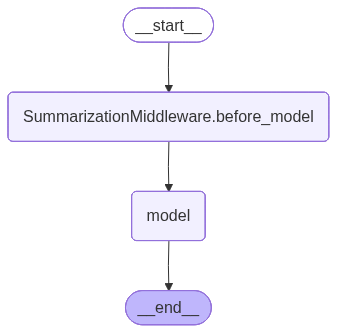

In [28]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

agent = create_agent(
    model=llm,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [29]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [9]:
# Alternative test data
questions = [
    "What is 5+5?",
    "What is 10*9?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='174fd19e-c3ee-48c9-aa14-c36183c87700'), AIMessage(content='2 + 2 = 4.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51, 'completion_time': 0.006950316, 'completion_tokens_details': None, 'prompt_time': 0.01218629, 'prompt_tokens_details': None, 'queue_time': 0.036788934, 'total_time': 0.019136606}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d19-1905-71b2-bf58-5e5977ef701e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='174fd19e-c3ee-48c9-aa14-c36183c87700'), AIMessa

## token Size

In [38]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_core.messages.utils import (
    count_tokens_approximately,
)
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

main_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=300,
)

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""

    return f"""
Hotels in {city}:

1. Grand Hotel - $350
2. City Inn - $180
3. Budget Stay - $75
"""

agent = create_agent(
    model=main_llm,

    tools=[search_hotels],

    checkpointer=InMemorySaver(),

    system_prompt="""
Call tool only once.
Keep answers short.
Never repeat tool calls.
""",

    middleware=[
        SummarizationMiddleware(
            model="groq:llama-3.1-8b-instant",

            trigger=("tokens", 1000),

            keep=("tokens", 300),
        )
    ]
)

config = {
    "configurable": {
        "thread_id": "test-1"
    }
}

cities = [
    "Paris",
    "London",
    "Tokyo",
    "New York",
    "Dubai",
    "Singapore",
    "Sydney",
    "Berlin",
]

for city in cities:

    response = agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"Hotels in {city}"
                )
            ]
        },
        config=config
    )

    messages = response["messages"]

    tokens = count_tokens_approximately(
        messages
    )

    triggered = any(
        (
            msg.type == "human"
            and "summary of the conversation"
            in str(msg.content).lower()
        )
        for msg in messages
    )

    print(
        f"{city:<12} | "
        f"msgs={len(messages):<3} | "
        f"tokens={tokens:<5} | "
        f"summary_triggered={triggered}"
    )

Paris        | msgs=12  | tokens=516   | summary_triggered=True


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01ke70jchyedrs5ay4tzja32nf` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99436, Requested 805. Please try again in 3m28.224s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

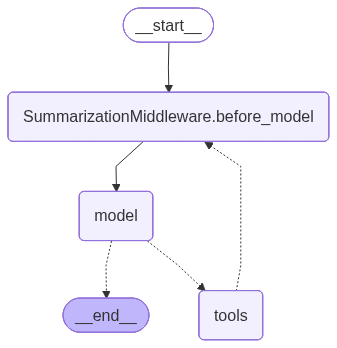

In [31]:
agent

In [10]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~149 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='b6555abb-79cf-484f-adca-782aa6c21184'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 53, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_db64b059be', 'id': 'chatcmpl-Co38pQM7GbvNkoeyZQplLXc20kKOx', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--5d9703e4-b2ec-4cce-a5b4-7bbcac8c1b9c-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_T1qZPF6uGKEEVx5WcsW8bs7e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 53, 'output_tokens': 15, 

### Fraction

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

# Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# Agent
agent = create_agent(
    model=llm,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("fraction", 0.005),
            keep=("fraction", 0.002),
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Approx token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test data
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )

    tokens = count_tokens(response["messages"])
    
    # Change according to model context window
    fraction = tokens / 128000

    print(
        f"{city}: ~{tokens} tokens "
        f"({fraction:.4%}), "
        f"{len(response['messages'])} msgs"
    )

    print(response["messages"])

Paris: ~57 tokens (0.0445%), 6 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='51733d53-9478-41e7-aa39-21d3155a219d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ymqmt5pm6', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 210, 'total_tokens': 225, 'completion_time': 0.039208378, 'completion_tokens_details': None, 'prompt_time': 0.009948567, 'prompt_tokens_details': None, 'queue_time': 0.008660385, 'total_time': 0.049156945}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d19-feac-7813-a27f-d56929e8fa1b-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'ymqmt5pm6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metada

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

# Groq model
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject"
                    ]
                },
                "read_email_tool": False,
            }
        )
    ]
)

In [13]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [14]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='967d1280-6e97-4938-a0fe-6cc526799434'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '706mctd43', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.052886198, 'completion_tokens_details': None, 'prompt_time': 0.024032878, 'prompt_tokens_details': None, 'queue_time': 0.0542691, 'total_time': 0.076919076}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1a-c8e2-7c91-b60a-b68da689db5b-0', tool_calls=[{'name': 'send_email_tool', 'args': {'bod

In [15]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: Email sent to john@test.com with subject 'Hello' and body 'How are you?'


In [16]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='967d1280-6e97-4938-a0fe-6cc526799434'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '706mctd43', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.052886198, 'completion_tokens_details': None, 'prompt_time': 0.024032878, 'prompt_tokens_details': None, 'queue_time': 0.0542691, 'total_time': 0.076919076}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1a-c8e2-7c91-b60a-b68da689db5b-0', tool_calls=[{'name': 'send_email_tool', 'args': {'bod

### Reject

In [17]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.tools import tool

# Groq model
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

@tool
def send_email_tool(
    recipient: str,
    subject: str,
    body: str
) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject",
                    ],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [18]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [19]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: 


In [20]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='a8e10946-383d-4f72-8d8d-1e1d7cedad33'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'by65tkf9g', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 309, 'total_tokens': 341, 'completion_time': 0.057990364, 'completion_tokens_details': None, 'prompt_time': 0.015428796, 'prompt_tokens_details': None, 'queue_time': 0.053814571, 'total_time': 0.07341916}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1b-bb94-7cf0-8dc1-404d49388f2b-0', tool_calls=[{'name': 'send_email_tool', 'args': {'bo

### Editing

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langchain_core.tools import tool

# Groq LLM
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
)

@tool
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

@tool
def send_email_tool(
    recipient: str,
    subject: str,
    body: str
) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model=llm,
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": [
                        "approve",
                        "edit",
                        "reject"
                    ],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [22]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [23]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='0f8e35c4-e7b4-4beb-be04-4ee0682f315c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rajf7620c', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.061498879, 'completion_tokens_details': None, 'prompt_time': 0.028872789, 'prompt_tokens_details': None, 'queue_time': 0.05419681, 'total_time': 0.090371668}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1c-5072-7ce3-8337-48e8e7956444-0', tool_calls=[{'name': 'send_email_tool', 'args': {'body': 'Hello'

In [24]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: 


In [25]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='0f8e35c4-e7b4-4beb-be04-4ee0682f315c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'rajf7620c', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 307, 'total_tokens': 337, 'completion_time': 0.061498879, 'completion_tokens_details': None, 'prompt_time': 0.028872789, 'prompt_tokens_details': None, 'queue_time': 0.05419681, 'total_time': 0.090371668}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e0d1c-5072-7ce3-8337-48e8e7956444-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'ar